# Framing Spatial Hearing within the Free Energy Principle
## A hierarchical model of perceptual learning — trial-by-trial belief revision on Majdak et al. (2010)

This notebook fits the model described in

> Barumerli, R., Meyer-Kahlen, N., & Picinali, L. (2026). *Framing Spatial Hearing within the Free Energy Principle: A Hierarchical Model of Perceptual Learning.* International Workshop on Active Inference (IWAI 2026), poster + spotlight.

to the localisation-training data of Majdak, Goupell & Laback (2010), Experiment 2 (feedback block), and reproduces Figure 3 of the paper (`figures/fig_behavioral.pdf`, `figures/fig_param_avg.pdf`) and the goodness-of-fit numbers quoted in the text.

**Data.** Run `python data/download_data.py` once before executing this notebook; it fetches `data.mat` from the AMT auxiliary data and verifies its checksum.

**Runtime.** About 5 minutes on a laptop (the learning-rate fits use `joblib` across all cores).

The model equations are stated in the markdown cells that precede the corresponding code (sections 1–4 below); they match Appendix A of the paper.


## Step 0 — Setup


In [1]:
import os
import sys

# Repository root = the folder containing this notebook.
HERE = os.getcwd()
DATA_PATH = os.path.join(HERE, 'data', 'data.mat')
FIG_DIR   = os.path.join(HERE, 'figures')
os.makedirs(FIG_DIR, exist_ok=True)
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError('data/data.mat not found: run  python data/download_data.py  first.')

import numpy as np
import pandas as pd
import scipy.io
import scipy.optimize
import scipy.stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.special import i0, i1, ive, expit
from joblib import Parallel, delayed
from pybads import BADS

plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete.')


Setup complete.


## 1 — Generative model

Directions are expressed in interaural-polar coordinates $\boldsymbol{\varphi} = (\alpha, \beta)$ (Morimoto & Aokata, 1984): the lateral angle $\alpha \in [-90^\circ, 90^\circ]$ runs along the interaural axis and is cued by interaural time and level differences; the polar angle $\beta \in [0^\circ, 360^\circ)$ runs around the cone of confusion defined by $\alpha$ and is decoded from spectral-shape cues. Subscripts $t$ and $r$ denote target and response.

Circular quantities are modelled with the von Mises distribution

$$\mathcal{VM}(x;\,\mu,\kappa) = \frac{e^{\kappa\cos(x-\mu)}}{2\pi I_0(\kappa)},$$

where $I_0$ is the modified Bessel function of order zero and $\kappa$ is the concentration (precision). The listener model factorises into a lateral and a polar component,

$$p(\boldsymbol{\varphi}_r \mid \boldsymbol{\varphi}_t, \boldsymbol{\theta}) = p(\alpha_r \mid \alpha_t, \kappa_L)\; p(\beta_r \mid \alpha_r, \beta_t, \kappa_P, w),$$

with

$$p(\alpha_r \mid \alpha_t, \kappa_L) = \mathcal{VM}(\alpha_r;\,\alpha_t,\kappa_L),$$

$$p(\beta_r \mid \alpha_r, \beta_t, \kappa_P, w) = w\,\mathcal{VM}(\beta_r;\,\beta_t,\tilde\kappa_P) + (1-w)\,\mathcal{VM}(\beta_r;\,\pi-\beta_t,\tilde\kappa_P),$$

where $\tilde\kappa_P = \kappa_P\cos^2(\alpha_r)$ accounts for the geometric compression of the cone of confusion at lateral angles, and $w \in (0,1)$ is the probability of resolving the correct hemifield. The two mixture components share the same concentration: hemifield confusion affects where the response lands, not how tightly it clusters.

The beliefs revised by learning are $\boldsymbol{\theta} = (\kappa_L, \kappa_P, w)$: lateral precision, polar precision and hemifield disambiguation.

**Two uses of the cone of confusion.** At perception time the listener has no access to the true lateral angle, so the generative model above conditions on the inferred cone $\alpha_r$. The likelihood used by the *experimenter* to fit $\boldsymbol{\theta}_0$ and the learning rates describes the response given the true target and is therefore conditioned on the true cone, $\tilde\kappa_P = \kappa_P\cos^2(\alpha_t)$; the same factor enters the belief update (section 3), which happens after visual feedback has revealed the target.

The functions below implement the maximum-likelihood fit of this model on a block of trials (used for the baseline beliefs $\boldsymbol{\theta}_0$), and the conversion between $\kappa$ and circular standard deviation.


In [2]:
# localisation model fitting functions
def kappa_to_sigma(kappa):
    """Circular SD (degrees) from von Mises concentration κ."""
    rho = float(i1(float(kappa)) / i0(float(kappa)))
    return float(np.rad2deg(np.sqrt(-2.0 * np.log(max(rho, 1e-10)))))


def sigma_to_kappa(sigma_deg):
    """Von Mises concentration κ from circular SD (degrees)."""
    target = np.exp(-0.5 * np.deg2rad(sigma_deg) ** 2)
    try:
        return float(scipy.optimize.brentq(
            lambda k: i1(k) / i0(k) - target, 1e-6, 500.0))
    except Exception:
        return 1.0


def fit_vm_polar(data_array):
    """
    MLE of von Mises mixture with cos²(lat) correction — all trials used.
    Model: p(φ|κ,w,λ) = w·VM(φ; φ_t, κ·cos²λ) + (1-w)·VM(π-φ_t; φ_t, κ·cos²λ)
    Returns dict: kappa_hat, w_hat, sigma_hat, n_trials.
    """
    lat   = np.deg2rad(data_array[:, 4])
    phi_t = np.deg2rad(data_array[:, 5])
    phi_r = np.deg2rad(data_array[:, 7])
    cos2  = np.cos(lat) ** 2
    eps_c = phi_r - phi_t
    eps_m = phi_r - (np.pi - phi_t)
    n     = len(phi_r)

    def nll(params):
        kappa = np.exp(params[0])
        w     = 1.0 / (1.0 + np.exp(-params[1]))
        ke    = kappa * cos2
        log_norm = np.log(2 * np.pi) + np.log(ive(0, ke)) + ke
        lp_c = ke * np.cos(eps_c) - log_norm
        lp_m = ke * np.cos(eps_m) - log_norm
        p = w * np.exp(lp_c) + (1.0 - w) * np.exp(lp_m)
        return -np.sum(np.log(np.maximum(p, 1e-300))) / n

    best = None
    for k0 in [0.5, 2.0, 5.0, 10.0]:
        for w0 in [0.6, 0.8, 0.95]:
            x0  = np.array([np.log(k0), np.log(w0 / (1.0 - w0))])
            res = scipy.optimize.minimize(nll, x0, method='Nelder-Mead',
                      options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 20000})
            if best is None or res.fun < best.fun:
                best = res

    kappa_hat = float(np.clip(np.exp(best.x[0]), 1e-3, 200.0))
    w_hat     = float(1.0 / (1.0 + np.exp(-best.x[1])))
    sigma_hat = kappa_to_sigma(kappa_hat)
    return {'kappa_hat': kappa_hat, 'w_hat': w_hat,
            'sigma_hat': sigma_hat, 'n_trials': n}


def fit_vm_lateral(data_array):
    """
    MLE of a single von Mises for lateral responses: VM(λ_resp; λ_targ, κ_L).
    No mixture needed (no lateral front/back confusion).
    Returns dict: kappa_lat, sigma_lat, n_trials.
    """
    lat_t = np.deg2rad(data_array[:, 4])
    lat_r = np.deg2rad(data_array[:, 6])
    eps   = lat_r - lat_t
    n     = len(eps)

    def nll(params):
        kappa = np.exp(params[0])
        log_norm = np.log(2 * np.pi) + np.log(ive(0, kappa)) + kappa
        return -np.sum(kappa * np.cos(eps) - log_norm) / n

    best = None
    for k0 in [0.5, 2.0, 5.0, 10.0, 20.0]:
        res = scipy.optimize.minimize(nll, [np.log(k0)], method='Nelder-Mead',
                  options={'xatol': 1e-6, 'fatol': 1e-6, 'maxiter': 10000})
        if best is None or res.fun < best.fun:
            best = res

    kappa_lat = float(np.clip(np.exp(best.x[0]), 1e-3, 200.0))
    return {'kappa_lat': kappa_lat, 'sigma_lat': kappa_to_sigma(kappa_lat), 'n_trials': n}


### Behavioural metrics

Rolling-window summaries used in Figure 3 (top row). Polar dispersion and hemifield (quadrant) error rate are weighted by $\cos^2(\alpha_t)$, consistently with the likelihood; lateral dispersion is the plain circular SD of the lateral error.


In [3]:
# behavioral metrics
def querr(lat_rad, pol_targ_rad, pol_resp_rad):
    """
    Cosine-weighted quadrant error rate.
    Each trial weighted by cos²(lat_targ) — consistent with κ_eff = κ·cos²(lat).
    At lat=0° reduces to standard Middlebrooks rate; at lat=90° weight→0.
    """
    err   = np.abs(((pol_resp_rad - pol_targ_rad) + np.pi) % (2 * np.pi) - np.pi)
    is_qe = (err >= np.pi / 2).astype(float)
    w     = np.cos(lat_rad) ** 2
    denom = w.sum()
    return float(100.0 * np.dot(w, is_qe) / denom) if denom > 1e-10 else np.nan


def sdPol(lat_rad, pol_targ_rad, pol_resp_rad):
    """
    Lateral-weighted RMS of polar errors after mirroring front/back confusions.
    Confusions (|err| >= 90°) are folded back: phi_r* = pi - phi_r.
    All trials contribute; weight: cos²(lat_targ).  Returns RMS in degrees.
    """
    err = ((pol_resp_rad - pol_targ_rad) + np.pi) % (2 * np.pi) - np.pi
    # mirror confusions into the correct hemifield
    confused      = np.abs(err) >= np.pi / 2
    pol_resp_corr = pol_resp_rad.copy()
    pol_resp_corr[confused] = np.pi - pol_resp_rad[confused]
    err_corr = ((pol_resp_corr - pol_targ_rad) + np.pi) % (2 * np.pi) - np.pi

    w     = np.cos(lat_rad) ** 2
    denom = w.sum()
    return float(np.rad2deg(np.sqrt(np.dot(w, err_corr ** 2) / denom))) if denom > 1e-10 else np.nan

def sdLat(lat_targ_rad, lat_resp_rad):
    """SD of lateral errors (degrees). VM on full circle is fine: κ_L is large,
    so tails outside ±90° are negligible."""
    err = ((lat_resp_rad - lat_targ_rad) + np.pi) % (2 * np.pi) - np.pi
    return float(np.rad2deg(np.std(err))) if len(err) >= 5 else np.nan


## 2 — Data

Majdak et al. (2010): ten normal-hearing listeners localised virtual sound sources (individual HRTFs) in a training study. Experiment 1 is naive localisation without feedback; Experiment 2 is the feedback block (visual feedback on the target after each response). Five listeners pointed manually (`Manual`), five with the head (`Head`). The paper uses the Manual group.

Baseline beliefs $\boldsymbol{\theta}_0 = (\kappa_{L,0}, \kappa_{P,0}, w_0)$ are estimated per subject by maximum likelihood on the last 100 trials of Experiment 1.


In [4]:
# prep data
GROUPS = {
    'NH8':'Head','NH11':'Head','NH13':'Head','NH14':'Head','NH19':'Head',
    'NH12':'Manual','NH15':'Manual','NH16':'Manual','NH17':'Manual','NH18':'Manual',
}

# Load Trials with feedback - Experiment 2 from Majdak 2010
SUBJECTS_ORDER = ['NH12','NH15','NH16','NH17','NH18',
                  'NH8','NH11','NH13','NH14','NH19']

COLORS = {sid: cm.tab10(i / 10) for i, sid in enumerate(SUBJECTS_ORDER)}


In [5]:
# load exp 2 data - localisation with feedback
def load_subjects(mat_path=DATA_PATH):
    mat = scipy.io.loadmat(mat_path, simplify_cells=True)
    subjects = {}
    for s in mat['subject']:
        sid  = s['id']
        lm   = np.real(s['expData'][4])   # Learn_M (Manual, cond index 4)
        lh   = np.real(s['expData'][5])   # Learn_H (Head,   cond index 5)
        data = lh if (lh.ndim == 2 and lh.shape[0] > 0) else lm
        subjects[sid] = {'data': data, 'group': GROUPS[sid], 'N': len(data)}
    return subjects


subjects = load_subjects()

print(f'Loaded {len(subjects)} subjects:')
for sid in SUBJECTS_ORDER:
    sd = subjects[sid]
    print(f'  {sid:5s}  {sd["group"]:6s}  {sd["N"]:5d} trials')

Loaded 10 subjects:
  NH12   Manual   1900 trials
  NH15   Manual   1200 trials
  NH16   Manual   2099 trials
  NH17   Manual    800 trials
  NH18   Manual    750 trials
  NH8    Head     1700 trials
  NH11   Head     1200 trials
  NH13   Head     1200 trials
  NH14   Head      600 trials
  NH19   Head     1000 trials


In [6]:
# load exp 1 data - localisation without feedback and estimate theta_0

def get_exp1_data(mat_path=DATA_PATH):
    """
    Load Experiment 1 HMD data.
    Head   → expData[1]  (HMD_H)
    Manual → expData[0]  (HMD_M)
    """
    mat = scipy.io.loadmat(mat_path, simplify_cells=True)
    exp1 = {}
    for s in mat['subject']:
        sid = s['id']
        if GROUPS[sid] == 'HMD':
            data = np.real(s['expData'][1])
        else:
            data = np.real(s['expData'][0])
        exp1[sid] = data
    return exp1


def fit_exp1(data_array):
    # from second half (better proxy for end-of-Exp1 state) - there is some procedural learning
    # half = len(data_array) // 2
    half = -100
    return {**fit_vm_polar(data_array[half:,]), **fit_vm_lateral(data_array[half:,])}


exp1_data = get_exp1_data()

print(f"{'Subject':7s} {'N_exp1':7s} {'kappa_0':8s} {'sigma_0':8s} "
      f"{'w_0':7s} {'kappa_lat_0':12s} {'n_trials':10s}")
print('-' * 77)

for sid in SUBJECTS_ORDER:
    data   = exp1_data[sid]
    result = fit_exp1(data)
    subjects[sid]['kappa_0']       = result['kappa_hat']
    subjects[sid]['w_0']           = result['w_hat']
    subjects[sid]['sigma_0']       = result['sigma_hat']
    subjects[sid]['kappa_lat_0']   = result['kappa_lat']
    subjects[sid]['exp1_fit']      = result
    k0  = result['kappa_hat']
    s0  = result['sigma_hat']
    w0  = result['w_hat']
    kl0 = result['kappa_lat']
    nc  = result['n_trials']
    N   = len(data)
    flag = ' <- NaN' if np.isnan(k0) else ''
    print(f"{sid:7s} {N:7d} {k0:8.3f} {s0:8.1f} {w0:7.3f} "
          f"{kl0:12.3f} {nc:10d}{flag}")


Subject N_exp1  kappa_0  sigma_0  w_0     kappa_lat_0  n_trials  
-----------------------------------------------------------------------------
NH12        399    7.477     21.7   0.888        8.314        100
NH15        400    2.383     43.3   0.831        8.775        100
NH16        400    4.307     29.7   0.708        8.544        100
NH17        400    4.287     29.8   0.600       18.986        100
NH18        399    0.850     78.5   0.843        6.016        100
NH8         400    3.596     33.1   0.819       17.468        100
NH11        397    0.971     73.8   0.858        9.206        100
NH13        399    4.147     30.4   0.612       11.191        100
NH14        400    6.597     23.3   0.988       12.966        100
NH19        400    9.235     19.4   0.932       28.599        100


## 3 — Free energy, natural gradient and update equations

For a recognition density $q(\boldsymbol{\theta})$ over the beliefs $\boldsymbol{\theta} = (\kappa_L, \kappa_P, w)$, the variational free energy at trial $i$ is

$$\mathcal{F}_i = \mathrm{KL}\!\left[q(\boldsymbol{\theta})\,\|\,p(\boldsymbol{\theta})\right] - \mathbb{E}_{q}\!\left[\log p(\boldsymbol{\varphi}_r \mid \boldsymbol{\varphi}_t, \boldsymbol{\theta})\right].$$

Under a Laplace approximation ($q$ Gaussian centred on the current point estimate $\boldsymbol{\theta}_i$) and a flat prior, the complexity term is constant in $\boldsymbol{\theta}_i$, so $\mathcal{F}_i = -\log p(\boldsymbol{\varphi}_r \mid \boldsymbol{\varphi}_t, \boldsymbol{\theta}_i) + \mathrm{const}$ (Buckley et al., 2017): belief revision amounts to online likelihood ascent. Beliefs are revised by natural-gradient descent (Amari, 1998),

$$\boldsymbol{\theta}_{i+1} = \boldsymbol{\theta}_i - \eta\,\mathcal{I}(\boldsymbol{\theta}_i)^{-1}\nabla_{\boldsymbol{\theta}}\mathcal{F}_i,$$

where $\mathcal{I}$ is the Fisher information. For a von Mises concentration, $\mathcal{I}(\kappa) = A'(\kappa) = 1 - A(\kappa)^2 - A(\kappa)/\kappa$, with $A(\kappa) = I_1(\kappa)/I_0(\kappa)$ the Bessel ratio, i.e. the expected value of $\cos(x-\mu)$. For the hemifield weight, parameterised through its logit $\psi = \log\frac{w}{1-w}$, $\mathcal{I}(\psi) = w(1-w)$. Because the likelihood factorises, the three updates are decoupled.

### Update equations

Let $\mathcal{VM}_c = \mathcal{VM}(\beta_r;\,\beta_t,\tilde\kappa_{P,i})$ and $\mathcal{VM}_m = \mathcal{VM}(\beta_r;\,\pi-\beta_t,\tilde\kappa_{P,i})$ denote the correct- and mirror-hemifield components of the polar mixture evaluated at the response on trial $i$, with $\tilde\kappa_{P,i} = \kappa_{P,i}\cos^2(\alpha_t)$, and $p_i = w_i\mathcal{VM}_c + (1-w_i)\mathcal{VM}_m$ the polar mixture likelihood. The updates are

$$\kappa_{P,i+1} = \kappa_{P,i} + \frac{\eta_P\,\cos^2(\alpha_t)}{A'(\kappa_{P,i})}\bigl[r_i - A(\kappa_{P,i})\bigr],$$

$$\psi_{i+1} = \psi_i + \eta_w\,\frac{\mathcal{VM}_c - \mathcal{VM}_m}{p_i}, \qquad w_{i+1} = \sigma(\psi_{i+1}),$$

$$\kappa_{L,i+1} = \kappa_{L,i} + \frac{\eta_L}{A'(\kappa_{L,i})}\bigl[\cos(\alpha_r-\alpha_t) - A(\kappa_{L,i})\bigr],$$

where $\sigma$ is the logistic function and

$$r_i = \frac{w_i\cos(\beta_r-\beta_t)\,\mathcal{VM}_c + (1-w_i)\cos(\beta_r-\pi+\beta_t)\,\mathcal{VM}_m}{p_i}$$

is the responsibility-weighted cosine alignment between response and target. Each bracketed term is a prediction error: the observed alignment minus the alignment expected under the current belief. The cone of confusion enters twice: at perception time the generative model conditions on the inferred cone $\alpha_r$ (section 1); at update time the visual feedback reveals the true direction, so $\mathcal{F}$ is evaluated with the true cone and the $\kappa_P$ step is scaled by $\cos^2(\alpha_t)$, the same factor used in the fitting likelihood. For $w$, the Fisher information cancels the logistic derivative exactly, and the logit parameterisation keeps $w \in (0,1)$ without projection.

Numerical details: $A'(\kappa)$ is floored at $10^{-4}$ (it decays as $1/(4\kappa^2)$), and $\kappa$ values are clipped to $[0.01, 200]$.


In [7]:
# FEP trial-by-trial update functions defined (polar + lateral, w in logit space).

def bessel_ratio(kappa):
    """A(κ) = I₁(κ)/I₀(κ), numerically stable."""
    kappa = float(kappa)
    if kappa < 1e-10:
        return 0.0
    if kappa > 500:
        return 1.0 - 1.0 / (2.0 * kappa) - 1.0 / (8.0 * kappa ** 2)
    return float(i1(kappa) / i0(kappa))

def A_prime(kappa):
    """Exact Fisher information for VM concentration κ: I(κ) = A'(κ) = 1 - A(κ)² - A(κ)/κ.
    Floored at 1e-4 for numerical stability at large κ."""
    a = bessel_ratio(kappa)
    return max(1.0 - a ** 2 - a / max(kappa, 1e-10), 1e-4)

def fep_trial_update(kappa, psi, kappa_lat,
                     phi_resp, phi_targ, lat_resp, lat_targ,
                     eta_k, eta_w, eta_L):
    """
    Single-trial FEP natural-gradient update for κ_pol, w, and κ_lat.
    Polar: κ_eff = κ·cos²(lat_targ): after visual feedback the belief about the cone is the true one
    (changed 2026-09-18 from lat_resp).  Lateral: plain VM, no correction.
    All angles in radians.  Returns (kappa_new, psi_new, kappa_lat_new).
    """
    w         = float(expit(psi))
    cos2      = np.cos(lat_targ) ** 2
    kappa_eff = max(kappa * cos2, 1e-6)

    # ── polar ──────────────────────────────────────────────────────────────
    eps_c = phi_resp - phi_targ
    eps_m = phi_resp - (np.pi - phi_targ)
    log_norm = np.log(2 * np.pi) + np.log(ive(0, kappa_eff)) + kappa_eff
    lvm_c = kappa_eff * np.cos(eps_c) - log_norm
    lvm_m = kappa_eff * np.cos(eps_m) - log_norm
    vm_c  = np.exp(lvm_c)
    vm_m  = np.exp(lvm_m)
    p_k   = w * vm_c + (1 - w) * vm_m

    if p_k >= 1e-300:
        r_k       = (w * np.cos(eps_c) * vm_c + (1 - w) * np.cos(eps_m) * vm_m) / p_k
        A_k       = bessel_ratio(kappa)
        dw        = (vm_c - vm_m) / p_k
        kappa_new = float(np.clip(
            kappa + eta_k * cos2 * (r_k - A_k) / A_prime(kappa),
            0.01, 200.0))
        psi_new   = float(psi + eta_w * dw)
    else:
        kappa_new, psi_new = kappa, psi

    # ── lateral ────────────────────────────────────────────────────────────
    eps_lat       = lat_resp - lat_targ
    A_lat         = bessel_ratio(kappa_lat)
    kappa_lat_new = float(np.clip(
        kappa_lat + eta_L * (np.cos(eps_lat) - A_lat) / A_prime(kappa_lat),
        0.01, 200.0))

    return kappa_new, psi_new, kappa_lat_new

def run_fep_trajectory(data_array, kappa_0, w_0, kappa_lat_0, eta_k, eta_w, eta_L):
    """
    Run trial-by-trial FEP gradient update over all Experiment 2 trials.
    Returns kappa_pol_traj, w_traj, kappa_lat_traj (length N+1), trial_idx (0..N).
    """
    N                 = len(data_array)
    kappa_pol_traj    = np.zeros(N + 1)
    w_traj            = np.zeros(N + 1)
    kappa_lat_traj    = np.zeros(N + 1)
    kappa_pol_traj[0] = kappa_0
    w_traj[0]         = w_0
    kappa_lat_traj[0] = kappa_lat_0
    psi = float(np.log(w_0 / (1.0 - w_0)))

    for k in range(N):
        kk_pol   = kappa_pol_traj[k]
        kk_lat   = kappa_lat_traj[k]
        lat_targ = np.deg2rad(data_array[k, 4])
        lat_resp = np.deg2rad(data_array[k, 6])

        phi_targ = np.deg2rad(data_array[k, 5])
        phi_resp = np.deg2rad(data_array[k, 7])
        kk_pol, psi, kk_lat = fep_trial_update(kk_pol, psi, kk_lat,
                                               phi_resp, phi_targ, lat_resp, lat_targ,
                                               eta_k, eta_w, eta_L)
        kappa_pol_traj[k + 1] = kk_pol
        w_traj[k + 1]         = float(expit(psi))
        kappa_lat_traj[k + 1] = kk_lat

    return kappa_pol_traj, w_traj, kappa_lat_traj, np.arange(N + 1)

print('FEP trial-by-trial update functions defined (polar + lateral, w in logit space).')


FEP trial-by-trial update functions defined (polar + lateral, w in logit space).


## 4 — Parameter estimation

Initial beliefs $\boldsymbol{\theta}_0$ come from the Experiment 1 fit (section 2). The learning rates $(\eta_L, \eta_P, \eta_w)$ are the only free parameters of the learning model. They are fitted per subject by minimising the summed negative log-likelihood of the responses in the feedback block under the sequential updates of section 3,

$$\mathcal{L}(\eta_P, \eta_w, \eta_L) = -\sum_{i=1}^{N}\Bigl[\log p(\beta_{r,i} \mid \alpha_{t,i}, \beta_{t,i}, \kappa_{P,i}, w_i) + \log p(\alpha_{r,i} \mid \alpha_{t,i}, \kappa_{L,i})\Bigr],$$

where $(\kappa_{P,i}, w_i, \kappa_{L,i})$ is the belief trajectory generated by the updates from $\boldsymbol{\theta}_0$. Because the likelihood factorises, $(\eta_P, \eta_w)$ and $\eta_L$ are estimated independently. The optimiser is Bayesian adaptive direct search (BADS; Acerbi & Ma, 2017). Note that BADS is stochastic: refits reproduce the learning rates up to optimiser noise. In the code `eta_k` stands for $\eta_P$.


In [8]:
# Estimate etas
# Objective: joint NLL over polar + lateral under running FEP model.
# κ₀/w₀/κ_L₀ fixed from Exp 1.  Fitted per subject: η_κ, η_L, η_w.

def nll_trajectory(data_array, kappa_pol_0, w_0, kappa_lat_0, eta_k, eta_w, eta_L):
    """Joint polar + lateral NLL under the running FEP model."""
    kappa_pol     = kappa_pol_0
    kappa_lat = kappa_lat_0
    psi       = float(np.log(w_0 / (1.0 - w_0)))
    nll       = 0.0
    n         = 0
    for trial in data_array:
        lat_targ = np.deg2rad(trial[4])
        phi_resp = np.deg2rad(trial[7])
        phi_targ = np.deg2rad(trial[5])
        lat_resp = np.deg2rad(trial[6])

        # polar NLL (cos²-corrected)
        kappa_eff = max(kappa_pol * np.cos(lat_targ) ** 2, 1e-6)
        w = float(expit(psi))
        log_norm_pol = np.log(2 * np.pi) + np.log(ive(0, kappa_eff)) + kappa_eff
        lvm_c = kappa_eff * np.cos(phi_resp - phi_targ)          - log_norm_pol
        lvm_m = kappa_eff * np.cos(phi_resp - (np.pi - phi_targ)) - log_norm_pol
        p_pol = w * np.exp(lvm_c) + (1 - w) * np.exp(lvm_m)

        # lateral NLL
        log_norm_lat = np.log(2 * np.pi) + np.log(ive(0, kappa_lat)) + kappa_lat
        p_lat = np.exp(kappa_lat * np.cos(lat_resp - lat_targ) - log_norm_lat)

        nll -= np.log(max(p_pol, 1e-300)) + np.log(max(p_lat, 1e-300))
        kappa_pol, psi, kappa_lat = fep_trial_update(
            kappa_pol, psi, kappa_lat,
            phi_resp, phi_targ, lat_resp, lat_targ,
            eta_k, eta_w, eta_L)
        n += 1
    return nll


## fit participants
LB  = np.array([1e-15, 1e-4, 1e-4])
PLB = np.array([0.01, 10.0, 0.1])
PUB = np.array([5.0,  500.0,   0.5])
UB  = np.array([20.0, 1000.0,  1.0])

def fit_eta_subject(sid):
    kappa_0     = subjects[sid].get('kappa_0')
    w_0         = subjects[sid].get('w_0')
    kappa_lat_0 = subjects[sid].get('kappa_lat_0')
    if any(v is None or np.isnan(v) for v in [kappa_0, w_0, kappa_lat_0]):
        return sid, None

    data = subjects[sid]['data']

    def objective(params):
        eta_k, eta_L, eta_w = float(params[0]), float(params[1]), float(params[2])
        return nll_trajectory(data, kappa_0, w_0, kappa_lat_0, eta_k, eta_w, eta_L)

    x0 = (PLB + PUB) / 2.0
    try:
        bads   = BADS(objective, x0, LB, UB, PLB, PUB,
                      options={'display': 'off'})
        result = bads.optimize()
        eta_k_fit, eta_L_fit, eta_w_fit = result['x']
        loss = float(result['fval'])
    except Exception:
        return sid, None


    return sid, {
        'eta_k': eta_k_fit,
        'eta_L': eta_L_fit,
        'eta_w': eta_w_fit,
        'loss':  loss
    }


print('Computing rolling window mixture fits and fitting η per subject via pyBADS...')
fit_results = Parallel(n_jobs=-1)(
    delayed(fit_eta_subject)(sid) for sid in SUBJECTS_ORDER
)


Computing rolling window mixture fits and fitting η per subject via pyBADS...


bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should not be too close. Moving plausible bounds.
bads:TooCloseBounds: For each variable, hard and plausible bounds should

In [9]:

print(f'\n{"Subject":7s} {"kappa_0":8s} {"w_0":6s} {"kL0":7s} {"eta_k":8s} {"eta_L":8s} {"eta_w":8s} {"loss":8s}')
print('-' * 62)
for sid, res in fit_results:
    k0  = subjects[sid].get('kappa_0',     np.nan)
    w0  = subjects[sid].get('w_0',         np.nan)
    kl0 = subjects[sid].get('kappa_lat_0', np.nan)
    if res is None:
        print(f'{sid:7s}  FAILED')
        continue
    subjects[sid]['eta_k']      = res['eta_k']
    subjects[sid]['eta_L']      = res['eta_L']
    subjects[sid]['eta_w']      = res['eta_w']

    print(f'{sid:7s} {k0:8.3f} {w0:6.3f} {kl0:7.3f} {res["eta_k"]:8.15f} {res["eta_L"]:8.4f} {res["eta_w"]:8.4f} {res["loss"]:8.4f}')

# Store deterministic trajectories
for sid in SUBJECTS_ORDER:
    k0    = subjects[sid].get('kappa_0')
    w0    = subjects[sid].get('w_0')
    kl0   = subjects[sid].get('kappa_lat_0')
    eta_k = subjects[sid].get('eta_k')
    eta_w = subjects[sid].get('eta_w')
    eta_L = subjects[sid].get('eta_L')
    if any(v is None or np.isnan(v) for v in [k0, w0, kl0, eta_k, eta_w, eta_L]):
        continue
    kt, wt, klt, trial_idx = run_fep_trajectory(
        subjects[sid]['data'], k0, w0, kl0, eta_k, eta_w, eta_L
    )
    subjects[sid]['kappa_pol_traj']     = kt
    subjects[sid]['w_traj']         = wt
    subjects[sid]['kappa_lat_traj'] = klt
    subjects[sid]['trial_idx']      = trial_idx

eta_k_best = float(np.median([subjects[s]['eta_k'] for s in SUBJECTS_ORDER if 'eta_k' in subjects[s]]))
eta_L_best = float(np.median([subjects[s]['eta_L'] for s in SUBJECTS_ORDER if 'eta_L' in subjects[s]]))
eta_w_best = float(np.median([subjects[s]['eta_w'] for s in SUBJECTS_ORDER if 'eta_w' in subjects[s]]))
print(f'\nMedian η: eta_kappa={eta_k_best:.6f}, eta_L={eta_L_best:.6f}, eta_w={eta_w_best:.6f}')



Subject kappa_0  w_0    kL0     eta_k    eta_L    eta_w    loss    
--------------------------------------------------------------
NH12       7.477  0.888   8.314 0.000000015347035   0.0175   0.0044 1179.3373
NH15       2.383  0.831   8.775 0.022965849652323   0.0084   0.0062 1425.5128
NH16       4.307  0.708   8.544 0.000000000000043   0.0104   0.0134 2332.6947
NH17       4.287  0.600  18.986 0.000000000000219   0.0050   0.0226 1099.0457
NH18       0.850  0.843   6.016 0.082027737284901   0.0247   0.0202 1244.7831
NH8        3.596  0.819  17.468 0.000000000000064   0.0040   0.0001 2294.6904
NH11       0.971  0.858   9.206 0.038720321895040   0.0019   0.0002 2249.2056
NH13       4.147  0.612  11.191 0.000000000000452   0.0267   0.0023 2126.1334
NH14       6.597  0.988  12.966 0.000000000000014   0.0141   0.0190 441.8058
NH19       9.235  0.932  28.599 0.000000000000010   0.0041   1.0000 267.7854

Median η: eta_kappa=0.000000, eta_L=0.009365, eta_w=0.009800


## 5 — Figures and goodness of fit

Rolling-window behavioural trajectories (empirical vs. model rollout), the $R^2$ quoted in the paper, and the individual parameter trajectories (Figure 3 of the paper).


Using η: eta_kappa=0.000, eta_w=0.010
Using fitted kappa_0/w_0 per subject from grid search.


Simulation done.


/var/folders/qc/tn7q8gbx3d15rthd04c7wrjh0000gn/T/ipykernel_49889/2702106208.py:152: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  plt.tight_layout()
/opt/homebrew/Caskroom/miniconda/base/envs/bayesian_listener/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8320 (\N{SUBSCRIPT ZERO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


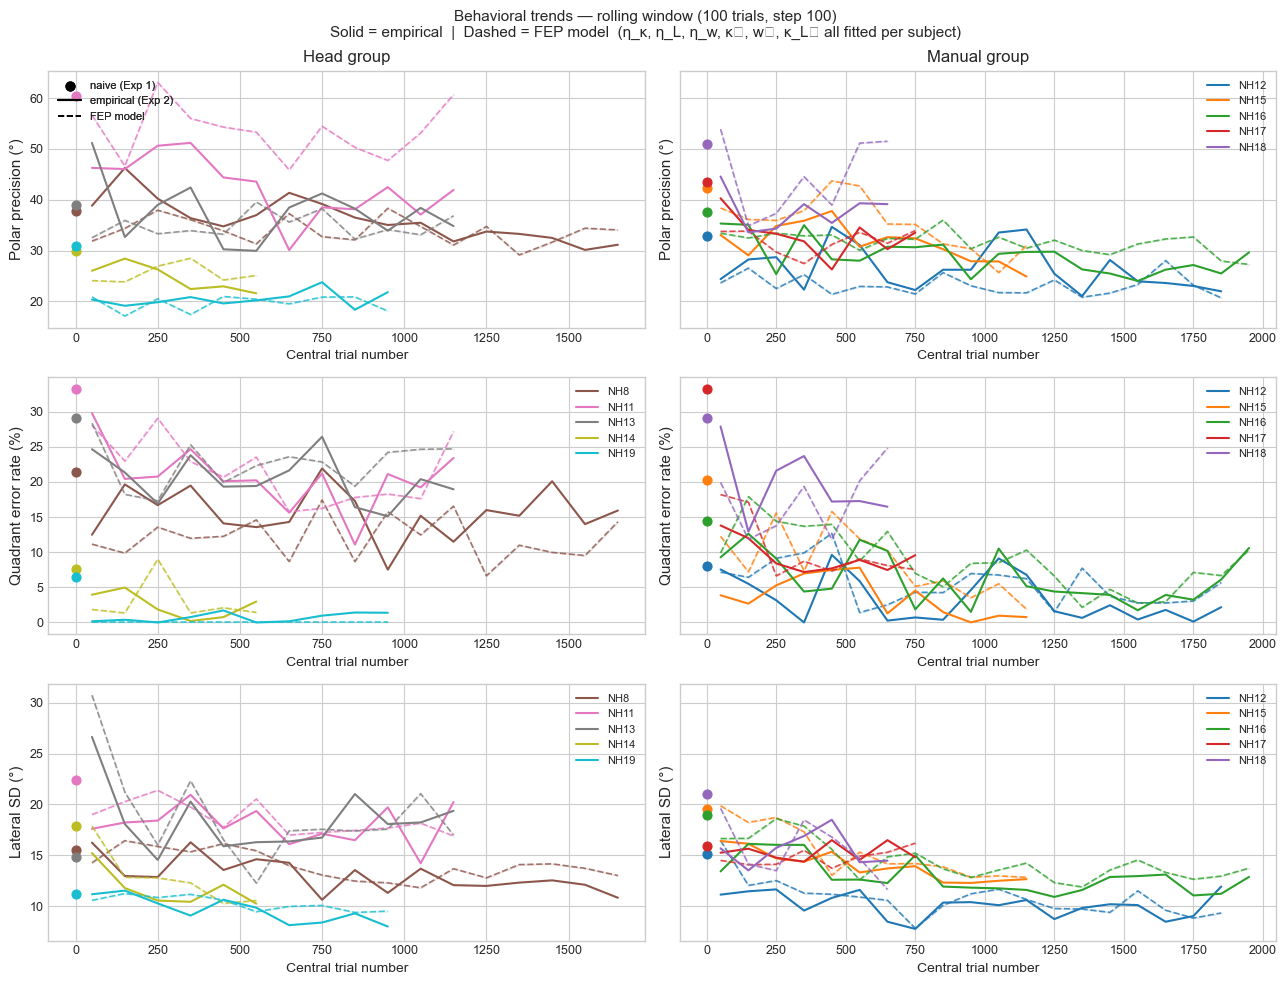

In [10]:
WINDOW = 100
STEP   = 100

def rolling_behavior(data, window=WINDOW, step=STEP):
    N            = len(data)
    lat_targ     = np.deg2rad(data[:, 4])
    pol_targ     = np.deg2rad(data[:, 5])
    lat_resp     = np.deg2rad(data[:, 6])
    pol_resp_loc = np.deg2rad(data[:, 8])
    pol_resp_all = np.deg2rad(data[:, 7])

    mids, sdPol_vals, querr_vals, rmslat_vals = [], [], [], []
    for start in range(0, N - window + 1, step):
        sl  = slice(start, start + window)
        mid = start + window // 2
        sdPol_vals.append(sdPol(lat_targ[sl], pol_targ[sl], pol_resp_loc[sl]))
        querr_vals.append(querr(lat_targ[sl], pol_targ[sl], pol_resp_all[sl]))
        rmslat_vals.append(sdLat(lat_targ[sl], lat_resp[sl]))
        mids.append(mid)

    return np.array(mids), np.array(sdPol_vals), np.array(querr_vals), np.array(rmslat_vals)

# Rolling empirical metrics
for sid in SUBJECTS_ORDER:
    mids, rp, qe, rl = rolling_behavior(subjects[sid]['data'])
    subjects[sid]['roll_mids']  = mids
    subjects[sid]['roll_sdPol'] = rp
    subjects[sid]['roll_querr'] = qe
    subjects[sid]['roll_sdLat'] = rl

# Naive (Exp 1) scalar metrics — used as horizontal reference in figure
for sid in SUBJECTS_ORDER:
    data_e1 = exp1_data[sid]
    win_e1  = min(WINDOW, len(data_e1))
    _, rp_e1, qe_e1, rl_e1 = rolling_behavior(data_e1, window=win_e1, step=win_e1)
    subjects[sid]['naive_sdPol']  = float(np.nanmean(rp_e1)) if len(rp_e1) > 0 else np.nan
    subjects[sid]['naive_querr']  = float(np.nanmean(qe_e1)) if len(qe_e1) > 0 else np.nan
    subjects[sid]['naive_sdLat']  = float(np.nanmean(rl_e1)) if len(rl_e1) > 0 else np.nan

print(f'Using η: eta_kappa={eta_k_best:.3f}, eta_w={eta_w_best:.3f}')
print(f'Using fitted kappa_0/w_0 per subject from grid search.')

# Single-pass simulated rollout with fitted parameters
sim_rng = np.random.default_rng(42)
for sid in SUBJECTS_ORDER:
    kappa_0     = subjects[sid].get('kappa_0')
    w_0         = subjects[sid].get('w_0')
    kappa_lat_0 = subjects[sid].get('kappa_lat_0')
    n           = len(subjects[sid]['roll_mids'])
    if kappa_lat_0 is None or np.isnan(kappa_lat_0):
        for key in ('model_sdPol_mean', 'model_sdPol_sd',
                    'model_querr_mean', 'model_querr_sd',
                    'model_sdLat_mean', 'model_sdLat_sd'):
            subjects[sid][key] = np.full(n, np.nan)
        continue

    kappa_all, w_all, kappa_lat_all, _ = run_fep_trajectory(
        subjects[sid]['data'], kappa_0, w_0, kappa_lat_0,
        subjects[sid]['eta_k'], subjects[sid]['eta_w'], subjects[sid]['eta_L'])

    mids    = subjects[sid]['roll_mids']
    data_sid = subjects[sid]['data']
    lat_rad  = np.deg2rad(data_sid[:, 4])
    pol_rad  = np.deg2rad(data_sid[:, 5])

    sdPol_arr = np.full(len(mids), np.nan)
    querr_arr = np.full(len(mids), np.nan)
    sdLat_arr = np.full(len(mids), np.nan)
    for mi, m in enumerate(mids):
        kk     = kappa_all[m]
        wk     = w_all[m]
        kk_lat = kappa_lat_all[m]
        half   = WINDOW // 2
        sl     = slice(max(0, m - half), min(len(data_sid), m + half))
        lat_sl = lat_rad[sl]
        pol_sl = pol_rad[sl]
        n_sl   = len(pol_sl)
        if n_sl < 5:
            continue
        noise_vm     = sim_rng.vonmises(0, kk, size=n_sl)
        use_c        = sim_rng.random(size=n_sl) < wk
        pol_sim      = np.where(use_c, pol_sl + noise_vm, (np.pi - pol_sl) + noise_vm)
        noise_lat_vm = sim_rng.vonmises(0, kk_lat, size=n_sl)
        lat_sim      = lat_sl + noise_lat_vm
        sdPol_arr[mi] = sdPol(lat_sl, pol_sl, pol_sim)
        querr_arr[mi] = querr(lat_sl, pol_sl, pol_sim)
        sdLat_arr[mi] = sdLat(lat_sl, lat_sim)

    subjects[sid]['model_sdPol_mean'] = sdPol_arr
    subjects[sid]['model_sdPol_sd']   = np.zeros(len(mids))
    subjects[sid]['model_querr_mean'] = querr_arr
    subjects[sid]['model_querr_sd']   = np.zeros(len(mids))
    subjects[sid]['model_sdLat_mean'] = sdLat_arr
    subjects[sid]['model_sdLat_sd']   = np.zeros(len(mids))

print('Simulation done.')

# Figure
HEAD   = ['NH8','NH11','NH13','NH14','NH19']
MANUAL = ['NH12','NH15','NH16','NH17','NH18']

fig, axes = plt.subplots(3, 2, figsize=(13, 10), sharey='row')
fig.subplots_adjust(hspace=0.35, wspace=0.2)

row_specs = [
    ('roll_sdPol',  'model_sdPol_mean',  'model_sdPol_sd',  'Polar precision (°)'),
    ('roll_querr',  'model_querr_mean',  'model_querr_sd',  'Quadrant error rate (%)'),
    ('roll_sdLat',  'model_sdLat_mean',  'model_sdLat_sd',  'Lateral SD (°)'),
]

for row, (emp_key, mean_key, sd_key, ylabel) in enumerate(row_specs):
    for col, (group_sids, gtitle) in enumerate(
        zip([HEAD, MANUAL], ['Head group', 'Manual group'])
    ):
        ax = axes[row][col]
        for sid in group_sids:
            c         = COLORS[sid]
            mids      = subjects[sid]['roll_mids']
            mu        = subjects[sid][mean_key]
            sd        = subjects[sid][sd_key]
            naive_key = {0: 'naive_sdPol', 1: 'naive_querr', 2: 'naive_sdLat'}[row]
            naive_val = subjects[sid][naive_key]
            if not np.isnan(naive_val):
                ax.scatter(0, naive_val, color=c, s=40, zorder=5, clip_on=False)
            ax.plot(mids, subjects[sid][emp_key], color=c, lw=1.5, label=sid)
            ax.plot(mids, mu,                     color=c, lw=1.2, ls='--', alpha=0.8)
            ax.fill_between(mids, mu - sd, mu + sd, color=c, alpha=0.15)
        ax.set_ylabel(ylabel, fontsize=11)
        ax.set_xlabel('Central trial number', fontsize=10)
        ax.tick_params(labelsize=9)
        ax.legend(fontsize=8, loc='upper right', framealpha=0.7)
        if row == 0:
            ax.set_title(gtitle, fontsize=12)

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
axes[0][0].add_artist(axes[0][0].legend(
    handles=[
        plt.scatter([], [], color='k', s=40,        label='naive (Exp 1)'),
        Line2D([0],[0], color='k', lw=1.5,          label='empirical (Exp 2)'),
        Line2D([0],[0], color='k', lw=1.2, ls='--', label='FEP model'),
    ],
    fontsize=8, loc='upper left', framealpha=0.7
))

fig.suptitle(
    f'Behavioral trends — rolling window ({WINDOW} trials, step {STEP})\n'
    f'Solid = empirical  |  Dashed = FEP model  '
    f'(η_κ, η_L, η_w, κ₀, w₀, κ_L₀ all fitted per subject)',
    fontsize=11
)
plt.tight_layout()
plt.show()
fig_behavior = fig


Only the Manual pointing condition is used in the paper: the Head condition shows no consistent trend over training in this data set. The figures below therefore show the Manual group.


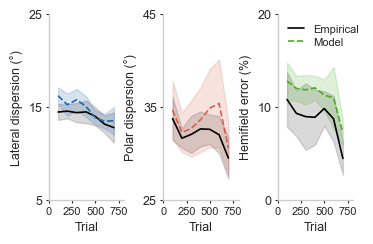

In [11]:
# ── Group-average figure — publication-ready (3 of 4 panels) ────────────────
from scipy.stats import iqr

MIN_N      = 1
MAX_TRIALS = 750

GROUPS_AVG = [
    ('Manual', [sid for sid in SUBJECTS_ORDER if subjects[sid]['group'] == 'Manual'], 'black'),
]

common_x = np.arange(STEP, max(subjects[sid]['N'] for sid in SUBJECTS_ORDER) + 1, STEP)
if MAX_TRIALS is not None:
    common_x = common_x[common_x <= MAX_TRIALS]

row_specs_avg = [
    ('roll_sdLat',  'model_sdLat_mean',  'naive_sdLat',  'Lateral dispersion (°)', '#2166ac'),
    ('roll_sdPol',  'model_sdPol_mean',  'naive_sdPol',  'Polar dispersion (°)', '#d6604d'),
    ('roll_querr',  'model_querr_mean',  'naive_querr',  'Hemifield error (%)', '#4dac26'),
]

def interp_to_grid(mids, values, grid):
    out  = np.full(len(grid), np.nan)
    mask = (grid >= mids[0]) & (grid <= mids[-1])
    if mask.any():
        out[mask] = np.interp(grid[mask], mids, values)
    return out

def precision_weighted_mean_se(arr, weights):
    n_x      = arr.shape[1]
    mean_out = np.full(n_x, np.nan)
    se_out   = np.full(n_x, np.nan)
    n_out    = np.zeros(n_x, dtype=int)
    for xi in range(n_x):
        col  = arr[:, xi]
        good = ~np.isnan(col)
        n    = good.sum()
        n_out[xi] = n
        if n < 2:
            continue
        w  = weights[good]
        v  = col[good]
        V1 = w.sum()
        V2 = (w ** 2).sum()
        mu = np.dot(w, v) / V1
        var_w = (V1 / (V1 ** 2 - V2)) * np.dot(w, (v - mu) ** 2)
        mean_out[xi] = mu
        se_out[xi]   = np.sqrt(var_w / n)
    return mean_out, se_out, n_out

# 1x4 layout: each panel = 345pt/4 wide; this figure = 3 panels wide
PT_TO_IN  = 1 / 72.27
PANEL_W   = (345 / 4) * PT_TO_IN   # ~1.194 in
FIG3_W    = PANEL_W * 3
FIG_H     = PANEL_W * 2
FS        = 9

# 3 side-by-side panels, independent x-axes
fig_avg2, axes_avg2 = plt.subplots(1, 3, figsize=(FIG3_W, FIG_H))
fig_avg2.subplots_adjust(wspace=0.52, left=0.14, right=0.99, top=0.92, bottom=0.14)
fig_avg2.patch.set_facecolor('none')

for col, (emp_key, mod_key, naive_key, ylabel, mcolor) in enumerate(row_specs_avg):
    ax = axes_avg2[col]
    handles = []
    ax.set_facecolor('none')

    for g_name, g_sids, g_color in GROUPS_AVG:
        emp_mat, mod_mat, naive_vals = [], [], []

        for sid in g_sids:
            mids = subjects[sid]['roll_mids']
            emp_mat.append(interp_to_grid(mids, subjects[sid][emp_key], common_x))
            mod_vals = subjects[sid].get(mod_key)
            if mod_vals is not None and not np.all(np.isnan(mod_vals)):
                mod_mat.append(interp_to_grid(mids, mod_vals, common_x))
            else:
                mod_mat.append(np.full(len(common_x), np.nan))
            nv = subjects[sid].get(naive_key, np.nan)
            if not np.isnan(nv):
                naive_vals.append(nv)

        emp_arr = np.array(emp_mat)
        mod_arr = np.array(mod_mat)
        emp_var = np.array([np.nanstd(r)**2 for r in emp_arr])
        mod_var = np.array([np.nanstd(r)**2 for r in mod_arr])
        emp_var = np.array([iqr(r, nan_policy = 'omit') for r in emp_arr])
        mod_var = np.array([iqr(r, nan_policy = 'omit') for r in mod_arr])
        emp_w   = np.where(emp_var > 1e-10, 1.0 / emp_var, 0.0)
        mod_w   = np.where(mod_var > 1e-10, 1.0 / mod_var, 0.0)
        emp_w   = np.where(emp_var > 1e-10, 1.0, 0.0)
        mod_w   = np.where(mod_var > 1e-10, 1.0, 0.0)

        emp_mean, emp_se, n_emp = precision_weighted_mean_se(emp_arr, emp_w)
        mod_mean, mod_se, n_mod = precision_weighted_mean_se(mod_arr, mod_w)

        valid = n_emp >= MIN_N
        xv    = common_x[valid]

        l_emp, = ax.plot(xv, emp_mean[valid], '-', color=g_color, lw=1.2,
                         label=f'Empirical')
        ax.fill_between(xv,
                        emp_mean[valid] - emp_se[valid],
                        emp_mean[valid] + emp_se[valid],
                        color=g_color, alpha=0.15)
        handles.append(l_emp)

        mod_valid = valid & (n_mod >= MIN_N)
        if mod_valid.any():
            xm = common_x[mod_valid]
            l_mod, = ax.plot(xm, mod_mean[mod_valid], '--', color=mcolor,
                             lw=1.2, alpha=1.0, label='Model')
            ax.fill_between(xm,
                            mod_mean[mod_valid] - mod_se[mod_valid],
                            mod_mean[mod_valid] + mod_se[mod_valid],
                            color=mcolor, alpha=0.18)
            handles.append(l_mod)

        # Exp 1 dot — placed in axis-fraction coords above the data range
        # if len(naive_vals) >= 1:
        #     nv_mean = np.nanmean(naive_vals)
        #     nv_se   = (np.nanstd(naive_vals, ddof=1) / np.sqrt(len(naive_vals))
        #                if len(naive_vals) >= 2 else 0.0)
        #     # draw in data y, but at a fixed left x using a broken-axis trick:
        #     # use inset_axes or just plot outside xlim with clip_on=False
        #     ax.errorbar(60, nv_mean, yerr=nv_se, fmt='o', color=g_color,
        #                 ms=3.5, capsize=2.5, lw=0.8, zorder=6, clip_on=False)
    ax.grid(False)
    ax.set_xlim(common_x[0] - 60, MAX_TRIALS + 60)
    ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_xlabel('Trial', fontsize=FS)
    ax.tick_params(labelsize=FS, length=2.5, pad=2)
    ax.spines[['top', 'right']].set_visible(False)

    # x ticks: sparse to avoid crowding in narrow panels
    xticks = np.arange(0, MAX_TRIALS + 1, 250)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(t)) for t in xticks], fontsize=FS - 1)

    if col == 0:
        ax.set_ylim([5, 25])
        ax.set_yticks([5, 15, 25])
    if col == 1:
        ax.set_ylim([25, 45])
        ax.set_yticks([25, 35, 45])
    # legend only on first panel
    if col == 2:
        ax.set_ylim([0, 20])
        ax.set_yticks([0, 10, 20])
        ax.legend(handles=handles, fontsize=FS - 1, loc='upper left',
                  frameon=False, handlelength=1.5, labelspacing=0.3)




# # shared "Exp 1 (no FB)" label below leftmost panel
# fig_avg2.text(0.03, 0.06, 'Exp 1', ha='center', va='top',
#               fontsize=FS - 1, color='black')

fig_avg2.patch.set_facecolor('none')
for _ax in axes_avg2:
    _ax.set_facecolor('none')
plt.show()
fig_group_avg2 = fig_avg2
fig_avg2.savefig(os.path.join(FIG_DIR, 'fig_behavioral.pdf'), format='pdf', bbox_inches='tight', dpi=600)


In [12]:
# ── Goodness-of-fit: R² on precision-weighted group-average trajectory ────────
from scipy.stats import pearsonr

GOF_TRIALS = 2099

metrics = [
    ('roll_sdPol',  'model_sdPol_mean', 'Polar SD'),
    ('roll_querr',  'model_querr_mean', 'Quadrant error'),
    ('roll_sdLat',  'model_sdLat_mean', 'Lateral SD'),
]

g_sids = [s for s in SUBJECTS_ORDER if subjects[s].get('group') == 'Manual']

print('Group-average R² (precision-weighted mean, 100-trial rolling windows)')
print(f'  n = {len(g_sids)} Manual subjects,  trials 1–{GOF_TRIALS}')
print()

for emp_key, mod_key, lbl in metrics:
    emp_mat, mod_mat = [], []
    for sid in g_sids:
        mids   = np.array(subjects[sid]['roll_mids'])
        mask   = mids <= GOF_TRIALS
        emp_mat.append(np.array(subjects[sid][emp_key])[mask])
        mod_vals = subjects[sid].get(mod_key)
        if mod_vals is not None and not np.all(np.isnan(mod_vals)):
            mod_mat.append(np.array(mod_vals)[mask])

    # pad to same length for array stacking
    max_n   = max(len(r) for r in emp_mat)
    def pad(rows):
        out = np.full((len(rows), max_n), np.nan)
        for i, r in enumerate(rows): out[i, :len(r)] = r
        return out

    emp_arr = pad(emp_mat)
    mod_arr = pad(mod_mat)
    emp_var = np.array([np.nanstd(r) for r in emp_mat])
    mod_var = np.array([np.nanstd(r) for r in mod_mat])
    emp_w   = np.where(emp_var > 1e-10, 1.0 , 0.0)
    mod_w   = np.where(mod_var > 1e-10, 1.0 , 0.0)

    emp_mean, _, n_emp = precision_weighted_mean_se(emp_arr, emp_w)
    mod_mean, _, n_mod = precision_weighted_mean_se(mod_arr, mod_w)

    valid = (n_emp >= 2) & (n_mod >= 2)
    e_v   = emp_mean[valid]
    m_v   = mod_mean[valid]
    ok    = ~np.isnan(e_v) & ~np.isnan(m_v)

    r, p = pearsonr(e_v[ok], m_v[ok])
    r2   = r ** 2
    print(f'  {lbl:<18}  R² = {r2:.3f}  (r = {r:+.3f},  p = {p:.3e},  n = {ok.sum()} windows)')

print()
print('One-sentence summary:')
summary = []
for emp_key, mod_key, lbl in metrics:
    emp_mat, mod_mat = [], []
    for sid in g_sids:
        mids = np.array(subjects[sid]['roll_mids'])
        mask = mids <= GOF_TRIALS
        emp_mat.append(np.array(subjects[sid][emp_key])[mask])
        mod_vals = subjects[sid].get(mod_key)
        if mod_vals is not None and not np.all(np.isnan(mod_vals)):
            mod_mat.append(np.array(mod_vals)[mask])
        else:
            mod_mat.append(np.full(mask.sum(), np.nan))
    max_n = max(len(r) for r in emp_mat)
    emp_arr = pad(emp_mat); mod_arr = pad(mod_mat)
    emp_var = np.array([np.nanstd(r) for r in emp_mat])
    mod_var = np.array([np.nanstd(r) for r in mod_mat])
    emp_w   = np.where(emp_var > 1e-10, 1.0 , 0.0)
    mod_w   = np.where(mod_var > 1e-10, 1.0 , 0.0)
    emp_mean, _, n_emp = precision_weighted_mean_se(emp_arr, emp_w)
    mod_mean, _, n_mod = precision_weighted_mean_se(mod_arr, mod_w)
    valid = (n_emp >= 2) & (n_mod >= 2)
    e_v = emp_mean[valid]; m_v = mod_mean[valid]
    ok  = ~np.isnan(e_v) & ~np.isnan(m_v)
    r, _ = pearsonr(e_v[ok], m_v[ok])
    summary.append((lbl, r))
lbl_str = ', '.join(f'{lbl} r={r:.2f}' for lbl, r in summary)
print(f'  The FEP model accounted for {lbl_str} of variance')
print(f'  in the group-average behavioral metrics (n={ok.sum()} rolling windows).')


Group-average R² (precision-weighted mean, 100-trial rolling windows)
  n = 5 Manual subjects,  trials 1–2099

  Polar SD            R² = 0.717  (r = +0.847,  p = 4.777e-06,  n = 19 windows)
  Quadrant error      R² = 0.861  (r = +0.928,  p = 1.054e-08,  n = 19 windows)
  Lateral SD          R² = 0.803  (r = +0.896,  p = 2.130e-07,  n = 19 windows)

One-sentence summary:
  The FEP model accounted for Polar SD r=0.85, Quadrant error r=0.93, Lateral SD r=0.90 of variance
  in the group-average behavioral metrics (n=19 rolling windows).


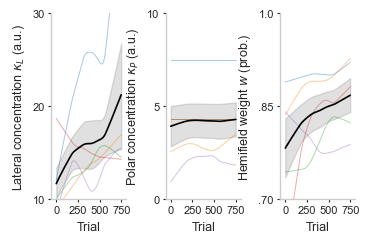

In [13]:
# ── Parameter trajectories — group average (precision-weighted) + LOESS ─────
from statsmodels.nonparametric.smoothers_lowess import lowess

LOESS_FRAC4 = 0.5
MAX_T4      = 750

param_specs4 = [
    ('kappa_lat_traj', r'Lateral concentration $\kappa_L$ (a.u.)',       True),
    ('kappa_pol_traj', r'Polar concentration $\kappa_P$ (a.u.)',          True),
    ('w_traj',         r'Hemifield weight $w$ (prob.)',  False),
]

# 1x4 layout: each panel = 345pt/4 wide; this figure = 3 panels wide
PT_TO_IN  = 1 / 72.27
PANEL_W   = (345 / 4) * PT_TO_IN   # ~1.194 in
FIG3_W    = PANEL_W * 3
FIG_H     = PANEL_W * 2
FS = 9

x_common = np.arange(MAX_T4 + 1)

fig_pavg, axes_pavg = plt.subplots(1,3, figsize=(FIG3_W, FIG_H))
fig_pavg.subplots_adjust(wspace=0.52, left=0.14, right=0.99, top=0.92, bottom=0.14)

fig_pavg.patch.set_facecolor('none')
m = -1
for ax, (pkey, ylabel, to_sigma) in zip(axes_pavg, param_specs4):
    m = m + 1
    ax.set_facecolor('none')

    mat = []
    for sid in g_sids:
        traj = np.asarray(subjects[sid][pkey], dtype=float)
        n   = min(len(traj), MAX_T4 + 1)
        row = np.full(MAX_T4 + 1, np.nan)
        row[:n] = traj[:n]
        mat.append(row)

    arr     = np.array(mat)
    n_valid = np.sum(~np.isnan(arr), axis=0)

    traj_sd = np.array([np.nanstd(row[~np.isnan(row)]) for row in mat])
    traj_sd = np.array([iqr(row[~np.isnan(row)]) for row in mat])
    traj_sd = np.array([1.0 for row in mat])
    weights = np.where(traj_sd > 1e-10, 1/traj_sd, 0.0)
    weights = weights / np.sum(weights)

    mu_w = np.full(MAX_T4 + 1, np.nan)
    se_w = np.full(MAX_T4 + 1, np.nan)
    for xi in x_common:
        col  = arr[:, xi]
        good = ~np.isnan(col)
        n    = good.sum()
        if n < 2:
            continue
        w  = weights[good]
        v  = col[good]
        V1 = w.sum();  V2 = (w**2).sum()
        mu_w[xi] = np.dot(w, v) / V1
        var_w    = (V1 / (V1**2 - V2)) * np.dot(w, (v - mu_w[xi])**2)
        se_w[xi] = np.sqrt(var_w / n)

    ok  = n_valid >= 2
    xok = x_common[ok]
    mok = mu_w[ok]
    sok = se_w[ok]

    mu_s = lowess(mok,       xok, frac=LOESS_FRAC4, it=3, return_sorted=False)
    hi_s = lowess(mok + sok, xok, frac=LOESS_FRAC4, it=3, return_sorted=False)
    lo_s = lowess(mok - sok, xok, frac=LOESS_FRAC4, it=3, return_sorted=False)

    # individual subject lines — LOESS-smoothed, low alpha
    for sid in g_sids:
        traj_i = np.asarray(subjects[sid][pkey], dtype=float)
        n_i    = min(len(traj_i), MAX_T4 + 1)
        xi     = np.arange(n_i)
        ok_i   = ~np.isnan(traj_i[:n_i])
        if ok_i.sum() < 4:
            continue
        sm_i = lowess(traj_i[:n_i][ok_i], xi[ok_i], frac=LOESS_FRAC4, it=3, return_sorted=False)
        ax.plot(xi[ok_i], sm_i, color=COLORS[sid], lw=0.7, alpha=0.4, label=sid)

    ax.fill_between(xok, lo_s, hi_s, color='black', alpha=0.12)
    ax.plot(xok, mu_s, '-', color='black', lw=1.2)
    ax.grid(False)

    ax.set_ylabel(ylabel, fontsize=FS)
    ax.set_xlabel('Trial', fontsize=FS)
    ax.tick_params(labelsize=FS - 1, length=2.5, pad=2)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlim(-60, MAX_T4 + 60)
    xticks = np.arange(0, MAX_T4 + 1, 250)
    ax.set_xticks(xticks)
    ax.set_xticklabels([str(int(t)) for t in xticks], fontsize=FS - 1)
    if m == 0:
        ax.set_ylim([10, 30])
        ax.set_yticks([10, 20, 30])
    if m == 1:
        ax.set_ylim([0, 10])
        ax.set_yticks([0, 5, 10])
    # legend only on first panel
    if m == 2:
        ax.set_ylim([0.7, 1])
        ax.set_yticks([.7, .85, 1])
        ax.set_yticklabels(('.70', '.85', '1.0'))
        #ax.legend(fontsize=8, loc='upper right', framealpha=0.7)



plt.show()
fig_pavg.savefig(os.path.join(FIG_DIR, 'fig_param_avg.pdf'), format='pdf', bbox_inches='tight', dpi=600)


Interpretation:

1. $\kappa_L$ improves for everyone, monotonically and relatively fast: task familiarisation / motor learning (rear pointing is motorically less practised and more variable, and improves with task experience rather than with the HRTF).
2. $w$ improves for everyone except NH18: HRTF-specific learning (front/back disambiguation requires learning the spectral cues).
3. $\kappa_P$ only improves for the low-$\kappa_P$ subjects: a ceiling effect, not a lack of HRTF learning.

The model therefore separates three processes with different timescales: motor learning ($\kappa_L$), perceptual disambiguation ($w$) and precision gain ($\kappa_P$).


## 6 — Exploratory analyses (not in the paper)

Cross-correlations between parameter trajectories and normalised trajectories for both pointing conditions. Kept for completeness; the cross-correlations are largely uninformative because $\kappa_P$ is flat for most listeners.


Subject   $\kappa_L$ vs $\kappa_P$   $\kappa_P$ vs $w$   $\kappa_L$ vs $w$
----------------------------------------------------------------------
NH12      +0.835*              +0.653*              +0.768*            
NH15      +0.166*              +0.773*              +0.160*            
NH16      -0.135*              +0.317*              +0.510*            
NH17      +0.456*              -0.480*              -0.697*            
NH18      +0.130*              +0.106*              +0.267*            


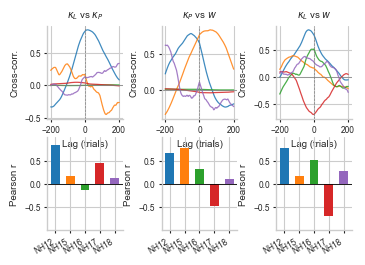

In [14]:
# ── Pairwise cross-correlations: κ_L vs κ_P,  κ_P vs w,  κ_L vs w ──────────

# correlation are mostly spurius (kP is flat...)
from scipy.signal import correlate
from scipy.stats import pearsonr
MAX_TRIALS3 = 750
PT_TO_IN = 1 / 72.27
PANEL_W  = (345 / 4) * PT_TO_IN
FIG3_W   = PANEL_W * 3
FIG_H    = PANEL_W * 2.2
FS       = 7
MAX_LAG  = 200

pairs = [
    ('kappa_lat_traj', 'kappa_pol_traj', r'$\kappa_L$ vs $\kappa_P$'),
    ('kappa_pol_traj', 'w_traj',         r'$\kappa_P$ vs $w$'),
    ('kappa_lat_traj', 'w_traj',         r'$\kappa_L$ vs $w$'),
]

fig_cc2, axes_cc2 = plt.subplots(2, 3, figsize=(FIG3_W, FIG_H))
fig_cc2.subplots_adjust(wspace=0.52, left=0.14, right=0.99, top=0.92, bottom=0.14)
fig_cc2.patch.set_facecolor('none')

r_table = {pair_label: {} for _, _, pair_label in pairs}

for col, (key_a, key_b, pair_label) in enumerate(pairs):
    ax_cc  = axes_cc2[0, col]   # cross-correlation curves
    ax_bar = axes_cc2[1, col]   # Pearson r bar

    r_vals, sids_used = [], []

    for sid in g_sids:
        a = np.asarray(subjects[sid][key_a], dtype=float)
        b = np.asarray(subjects[sid][key_b], dtype=float)
        n = min(len(a), len(b), MAX_TRIALS3 + 1)
        a, b = a[:n], b[:n]

        # detrend + z-score
        def detrend_z(x):
            x = x - np.linspace(x[0], x[-1], len(x))
            return (x - x.mean()) / (x.std() + 1e-10)

        a_d, b_d = detrend_z(a), detrend_z(b)
        cc   = correlate(b_d, a_d, mode='full') / n
        lags = np.arange(-(n-1), n)
        mask = np.abs(lags) <= MAX_LAG
        ax_cc.plot(lags[mask], cc[mask], color=COLORS[sid], lw=0.9, alpha=0.85)

        r, p = pearsonr(a_d, b_d)
        r_vals.append(r)
        sids_used.append(sid)
        r_table[pair_label][sid] = (r, p)

    ax_cc.axhline(0, color='gray', lw=0.5)
    ax_cc.axvline(0, color='gray', lw=0.5, ls='--')
    ax_cc.set_title(pair_label, fontsize=FS)
    ax_cc.set_xlabel('Lag (trials)', fontsize=FS)
    ax_cc.set_ylabel('Cross-corr.', fontsize=FS)

    xpos = np.arange(len(sids_used))
    ax_bar.bar(xpos, r_vals, color=[COLORS[s] for s in sids_used],
               width=0.6, edgecolor='none')
    ax_bar.axhline(0, color='black', lw=0.6)
    ax_bar.set_ylim(-1, 1)
    ax_bar.set_yticks([-0.5, 0, 0.5])
    ax_bar.set_xticks(xpos)
    ax_bar.set_xticklabels(sids_used, fontsize=FS - 1, rotation=30, ha='right')
    ax_bar.set_ylabel('Pearson r', fontsize=FS)

    for ax in [ax_cc, ax_bar]:
        ax.tick_params(labelsize=FS - 1, length=2.5, pad=2)
        ax.spines[['top', 'right']].set_visible(False)
        ax.set_facecolor('none')

# print summary table
print(f'{'Subject':<8}', end='')
for _, _, lbl in pairs:
    print(f'  {lbl:>18}', end='')
print()
print('-' * 70)
for sid in g_sids:
    print(f'{sid:<8}', end='')
    for _, _, lbl in pairs:
        r, p = r_table[lbl].get(sid, (np.nan, np.nan))
        sig = '*' if p < 0.05 else ' '
        print(f'  {r:+.3f}{sig}            ', end='')
    print()

plt.show()


Normalised parameter trajectories for the Head condition (no consistent learning trend).


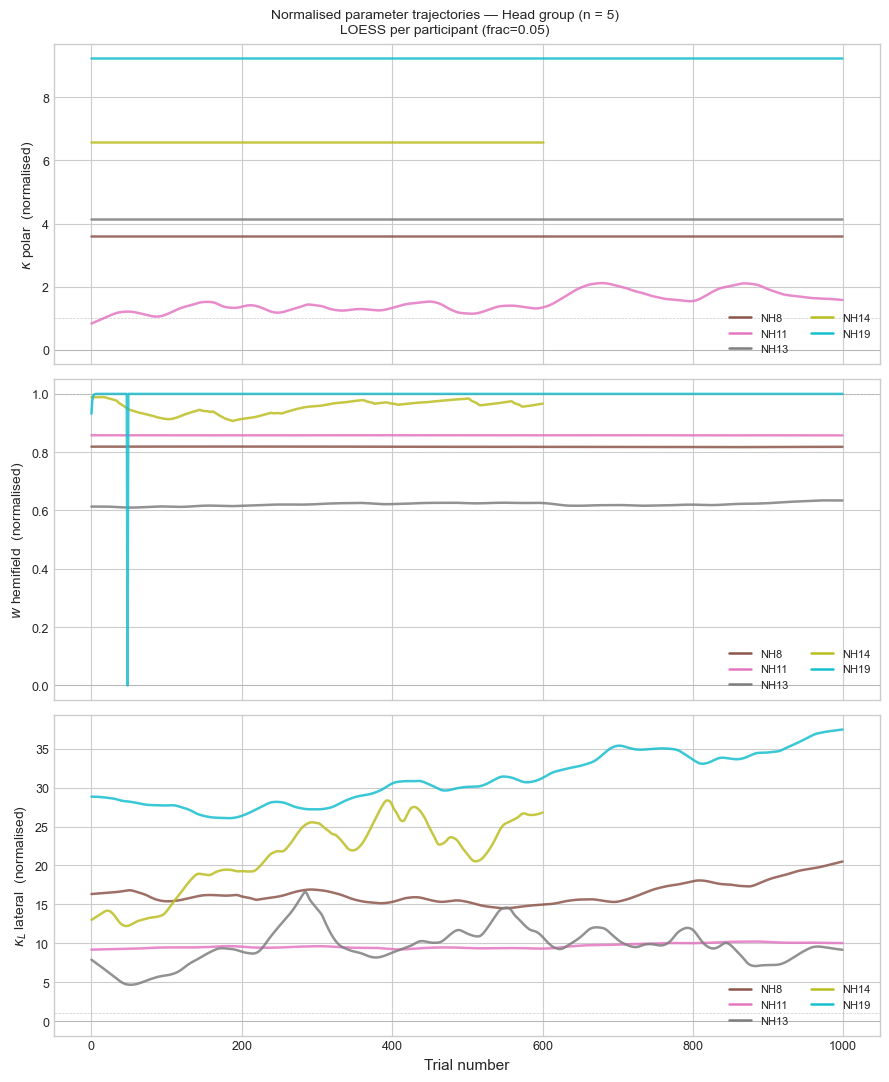

In [15]:
# ── Normalised parameter trajectories — 3×1 with LOESS per participant ───────
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.lines import Line2D
import matplotlib.patches as mpatches

NORM_GROUP2 = 'Head'
LOESS_FRAC2 = 0.05

param_specs2 = [
    ('kappa_pol_traj', r'$\kappa$ polar',     '#d6604d'),
    ('w_traj',         r'$w$ hemifield',      '#4dac26'),
    ('kappa_lat_traj', r'$\kappa_L$ lateral', '#2166ac'),
]

sids_norm2 = [s for s in SUBJECTS_ORDER
              if (subjects[s]['group'] == NORM_GROUP2)
              and all(subjects[s].get(pk) is not None for pk, _, _ in param_specs2)]

max_len2 = min(max(subjects[s]['N'] + 1 for s in sids_norm2), 1000)
x2       = np.arange(max_len2)

def norm_fl(vals):
    vals  = np.asarray(vals, dtype=float)
    start = float(np.mean(vals[:1]))
    denom = float(np.mean(vals[-1:])) -start
    # if abs(denom) < 1e-6:
    #     return np.zeros_like(vals)
    # return (vals - start) / denom
    return vals

fig3, axes3 = plt.subplots(3, 1, figsize=(9, 11), sharex=True)
fig3.subplots_adjust(hspace=0.12)

for ax, (pkey, label, color) in zip(axes3, param_specs2):
    for sid in sids_norm2:
        traj   = np.asarray(subjects[sid][pkey], dtype=float)
        normed = norm_fl(traj[:max_len2])
        xind   = np.arange(len(normed))
        ok     = ~np.isnan(normed)
        if ok.sum() < 4:
            continue
        sm = lowess(normed[ok], xind[ok], frac=LOESS_FRAC2, it=3, return_sorted=False)
        ax.plot(xind[ok], sm, color=COLORS[sid], lw=1.8, alpha=0.85, label=sid)
        # ax.plot(xind[ok], normed[ok], color=COLORS[sid], lw=1.8, alpha=0.85, label=sid)

    ax.axhline(0.0, color='gray', lw=0.5, ls='-',  alpha=0.4)
    ax.axhline(1.0, color='gray', lw=0.5, ls='--', alpha=0.4)
    ax.set_ylabel(f'{label}  (normalised)', fontsize=10)
    ax.tick_params(labelsize=9)

    legend_handles = [Line2D([0],[0], color=COLORS[s], lw=1.8, label=s) for s in sids_norm2]
    ax.legend(handles=legend_handles, fontsize=8, framealpha=0.8,
              loc='lower right', ncol=2)

axes3[-1].set_xlabel('Trial number', fontsize=11)
fig3.suptitle(
    f'Normalised parameter trajectories — {NORM_GROUP2} group (n = {len(sids_norm2)})\n'
    f'LOESS per participant (frac={LOESS_FRAC2})',
    fontsize=10
)
plt.tight_layout()
plt.show()


Normalised trajectories to compare learning across parameters (publication-style layout, Manual group).


/var/folders/qc/tn7q8gbx3d15rthd04c7wrjh0000gn/T/ipykernel_49889/2338822982.py:52: RuntimeWarning: divide by zero encountered in divide
  weights = np.where(traj_sd > 1e-10, 1.0 / traj_sd, 0.0)


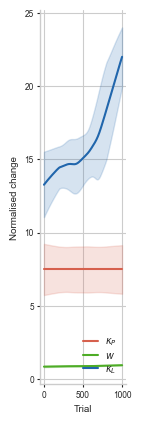

In [16]:
# ── Normalised parameter trajectories — publication-ready (1 of 4 panels) ────
from statsmodels.nonparametric.smoothers_lowess import lowess

NORM_GROUP = 'Manual'
LOESS_FRAC = 0.4
param_specs = [
    ('kappa_pol_traj', r'$\kappa_P$',  '#d6604d'),
    ('w_traj',         r'$w$',         '#4dac26'),
    ('kappa_lat_traj', r'$\kappa_L$',  '#2166ac'),
]

sids_norm = [s for s in SUBJECTS_ORDER
             if (subjects[s]['group'] == NORM_GROUP or NORM_GROUP == 'all')
             and all(subjects[s].get(pk) is not None for pk, _, _ in param_specs)]

def norm_first_last(vals):
    vals     = np.asarray(vals, dtype=float)
    baseline = float(vals[0])          # trial 0 = kappa_0 from Exp 1 fit
    denom    = float(np.mean(vals[-1:])) - baseline
    if abs(denom) < 1e-6:
        return np.zeros_like(vals)
    # return (vals - baseline) / denom
    return vals

max_len = min(max(subjects[s]['N'] + 1 for s in sids_norm), 1000)
x       = np.arange(max_len)

PT_TO_IN = 1 / 72.27
PANEL_W  = (345 / 4) * PT_TO_IN
FIG_H    = PANEL_W * 3.6
FS       = 7

fig_norm, ax = plt.subplots(figsize=(PANEL_W, FIG_H))
fig_norm.subplots_adjust(left=0.25, right=0.97, top=0.98, bottom=0.11)

for pkey, label, color in param_specs:
    padded = []
    for sid in sids_norm:
        traj   = np.asarray(subjects[sid][pkey], dtype=float)
        row    = np.full(max_len, np.nan)
        normed = norm_first_last(traj[:max_len])
        row[:len(normed)] = normed
        padded.append(row)

    arr     = np.array(padded)
    n_valid = np.sum(~np.isnan(arr), axis=0)

    # precision-weighted mean ± SE (weight = 1/SD[trajectory], same as metrics figure)
    traj_sd = np.array([np.nanstd(row[~np.isnan(row)]**2) for row in padded])
    traj_sd = np.array([np.nanstd(row[~np.isnan(row)]) for row in padded])
    # traj_sd = np.array([1.0 for row in padded])
    weights = np.where(traj_sd > 1e-10, 1.0 / traj_sd, 0.0)
    weights = weights / np.sum(weights, axis = 0)

    mu_w  = np.full(max_len, np.nan)
    se_w  = np.full(max_len, np.nan)
    for xi in range(max_len):
        col  = arr[:, xi]
        good = ~np.isnan(col)
        n    = good.sum()
        if n < 2:
            continue
        w  = weights[good]
        v  = col[good]
        V1 = w.sum()
        V2 = (w ** 2).sum()
        mu_w[xi]  = np.dot(w, v) / V1
        var_w     = (V1 / (V1 ** 2 - V2)) * np.dot(w, (v - mu_w[xi]) ** 2)
        se_w[xi]  = np.sqrt(var_w / n)

    ok  = n_valid >= 2
    xok = x[ok]
    mok = mu_w[ok]
    sok = se_w[ok]

    mu_s = lowess(mok,       xok, frac=LOESS_FRAC, it=3, return_sorted=False)
    hi_s = lowess(mok + sok, xok, frac=LOESS_FRAC, it=3, return_sorted=False)
    lo_s = lowess(mok - sok, xok, frac=LOESS_FRAC, it=3, return_sorted=False)

    ax.fill_between(xok, lo_s, hi_s, color=color, alpha=0.18)
    ax.plot(xok, mu_s, '-', color=color, lw=1.5, label=label)

ax.set_xlabel('Trial', fontsize=FS)
ax.set_ylabel('Normalised change', fontsize=FS)
ax.tick_params(labelsize=FS - 1, length=2.5, pad=2)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=FS, frameon=False, loc='lower right',
          handlelength=1.5, labelspacing=0.3)

fig_norm.patch.set_facecolor('none')
ax.set_facecolor('none')
plt.show()
fig_norm_pub = fig_norm


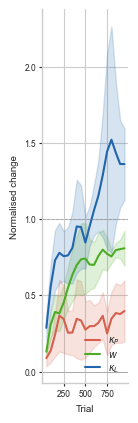

In [17]:
# ── Normalised parameter trajectories — rolling-window average (no LOESS) ────
# Same rolling window as behavioral metrics: window=100, step=100
# Precision-weighted mean ± SE across subjects

NORM_GROUP2 = 'Manual'
WINDOW_N    = 100
STEP_N      = 50
param_specs2 = [
    ('kappa_pol_traj', r'$\kappa_P$',  '#d6604d'),
    ('w_traj',         r'$w$',         '#4dac26'),
    ('kappa_lat_traj', r'$\kappa_L$',  '#2166ac'),
]

sids_norm2 = [s for s in SUBJECTS_ORDER
              if (subjects[s]['group'] == NORM_GROUP2 or NORM_GROUP2 == 'all')
              and all(subjects[s].get(pk) is not None for pk, _, _ in param_specs2)]

def norm_first_last_r(vals):
    vals     = np.asarray(vals, dtype=float)
    baseline = float(vals[0])
    denom    = float(np.mean(vals[-5:])) - baseline
    if abs(denom) < 1e-6:
        return np.zeros_like(vals)
    return (vals - baseline) / denom
    return vals - baseline

def rolling_param(normed, window=WINDOW_N, step=STEP_N):
    N = len(normed)
    mids, vals = [], []
    for start in range(0, N - window + 1, step):
        sl = normed[start:start + window]
        ok = ~np.isnan(sl)
        if ok.sum() < 5:
            continue
        mids.append(start + window // 2)
        vals.append(np.nanmean(sl))
    return np.array(mids), np.array(vals)

max_trials_n = min(max(subjects[s]['N'] + 1 for s in sids_norm2), 1000)
common_xn    = np.arange(STEP_N, max_trials_n, STEP_N)

PT_TO_IN = 1 / 72.27
PANEL_W  = (345 / 4) * PT_TO_IN
FIG_H    = PANEL_W * 3.6
FS       = 7

fig_norm2, ax2 = plt.subplots(figsize=(PANEL_W, FIG_H))
fig_norm2.subplots_adjust(left=0.25, right=0.97, top=0.98, bottom=0.11)

for pkey, label, color in param_specs2:
    roll_mat = []
    for sid in sids_norm2:
        traj   = np.asarray(subjects[sid][pkey], dtype=float)
        normed = norm_first_last_r(traj)
        mids_s, vals_s = rolling_param(normed)
        row = np.full(len(common_xn), np.nan)
        mask = (common_xn >= mids_s[0]) & (common_xn <= mids_s[-1])
        if mask.any():
            row[mask] = np.interp(common_xn[mask], mids_s, vals_s)
        roll_mat.append(row)

    arr     = np.array(roll_mat)
    n_valid = np.sum(~np.isnan(arr), axis=0)

    traj_sd = np.array([np.nanstd(row[~np.isnan(row)]) if np.any(~np.isnan(row)) else 0.0
                        for row in roll_mat])
    traj_sd = np.array([1.0 for row in roll_mat])
    weights = np.where(traj_sd > 1e-10, 1.0 / traj_sd, 0.0)

    mu_w = np.full(len(common_xn), np.nan)
    se_w = np.full(len(common_xn), np.nan)
    for xi in range(len(common_xn)):
        col  = arr[:, xi]
        good = ~np.isnan(col)
        n    = good.sum()
        if n < 2:
            continue
        w  = weights[good]
        v  = col[good]
        V1 = w.sum();  V2 = (w**2).sum()
        mu_w[xi] = np.dot(w, v) / V1
        var_w    = (V1 / (V1**2 - V2)) * np.dot(w, (v - mu_w[xi])**2)
        se_w[xi] = np.sqrt(var_w / n)

    ok  = n_valid >= 2
    xok = common_xn[ok]
    mok = mu_w[ok]
    sok = se_w[ok]

    ax2.fill_between(xok, mok - sok, mok + sok, color=color, alpha=0.18)
    ax2.plot(xok, mok, '-', color=color, lw=1.5, label=label)

ax2.axhline(0.0, color='gray', lw=0.6, ls='-',  alpha=0.5)
ax2.axhline(1.0, color='gray', lw=0.6, ls='--', alpha=0.5)
# ax2.set_ylim(-0.1, 1.6)
ax2.set_xlabel('Trial', fontsize=FS)
ax2.set_ylabel('Normalised change', fontsize=FS)
ax2.tick_params(labelsize=FS - 1, length=2.5, pad=2)
ax2.spines[['top', 'right']].set_visible(False)
ax2.legend(fontsize=FS, frameon=False, loc='lower right',
           handlelength=1.5, labelspacing=0.3)
fig_norm2.patch.set_facecolor('none')
ax2.set_facecolor('none')
plt.show()
fig_norm2_pub = fig_norm2
